In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
## make_blobs() -> Generating synthetic clustered datasets for testing clustering algorithms
X,y=make_blobs(n_samples=1000,centers=3,n_features=2) ## Here centers=3 represents the true clusters used to generate the dataset,but when applying K-Means we usually do not know the correct number of clusters beforehand.
## We later determine the optimal number of clusters using methods such as: Elbow Method Or Silhouette Scoring
## When working with real datasets: True number of clusters → unknown,So we try multiple values of K and validate them.


In [3]:
X

array([[ 9.21883604,  7.95968958],
       [-0.74964566,  6.12068593],
       [-0.40186805,  5.93822158],
       ...,
       [-0.5780703 ,  7.82075441],
       [ 6.39239038,  5.77202168],
       [ 0.4207267 ,  5.40520778]], shape=(1000, 2))

In [4]:
y ## We are not using these target labels bcz we are in unsupervised machine learning algorithm

array([2, 1, 1, 2, 1, 1, 1, 0, 1, 2, 0, 0, 0, 1, 1, 2, 2, 1, 1, 2, 0, 2,
       0, 1, 2, 2, 0, 0, 1, 1, 1, 0, 2, 2, 1, 2, 0, 0, 1, 1, 2, 1, 0, 1,
       2, 1, 2, 2, 2, 2, 1, 1, 2, 0, 1, 2, 2, 1, 1, 2, 1, 2, 0, 0, 2, 1,
       0, 1, 2, 1, 1, 2, 2, 0, 1, 2, 2, 0, 0, 0, 2, 2, 2, 0, 0, 1, 2, 2,
       1, 2, 0, 1, 0, 2, 1, 1, 1, 1, 1, 2, 2, 0, 1, 0, 1, 0, 1, 0, 1, 2,
       2, 2, 1, 2, 2, 0, 1, 2, 2, 2, 1, 2, 2, 1, 2, 1, 1, 0, 0, 2, 0, 0,
       1, 0, 1, 0, 1, 1, 2, 2, 0, 2, 2, 2, 2, 1, 1, 1, 1, 2, 0, 0, 0, 0,
       2, 0, 1, 2, 2, 0, 0, 2, 2, 2, 1, 1, 2, 1, 0, 1, 1, 1, 1, 2, 0, 0,
       0, 2, 2, 0, 1, 1, 2, 0, 2, 1, 1, 1, 1, 0, 2, 1, 2, 0, 2, 0, 0, 2,
       2, 0, 1, 0, 0, 2, 0, 0, 2, 2, 0, 0, 2, 1, 0, 0, 0, 1, 1, 2, 1, 2,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 2, 1, 0, 0, 2, 0,
       1, 1, 0, 2, 2, 1, 2, 1, 1, 0, 1, 2, 0, 1, 0, 0, 1, 0, 0, 2, 1, 0,
       0, 2, 0, 2, 1, 2, 0, 2, 0, 1, 0, 0, 1, 2, 1, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 0, 1, 0, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2,

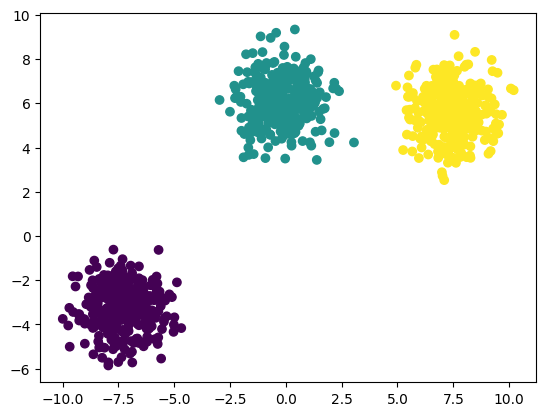

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [10]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler() ## StandardScaler is used to scale features so that they have comparable magnitudes.K-Means uses distance calculations.Without using scaling: clustering becomes biased toward large-scale features.After scaling: both features contribute equally

In [ ]:
from sklearn.model_selection import train_test_split ## train_test_split is NOT required, only used for demostration

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [14]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [15]:
from sklearn.cluster import KMeans

In [16]:
## Elbow method To select K Value(validate k value)
wcss=[] ## To store WCSS values for different K values.
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++") ## k-means++ solves this random initialization(centroids) by choosing better initial centroids.
    kmeans.fit(X_train_scaled) ## Applies the K-Means algorithm to the scaled training data in order to learn the cluster centroids and assign each data point to its nearest centroid
    wcss.append(kmeans.inertia_) ## kmeans.intertia_ gives WCSS value.

In [17]:
wcss

[1339.9999999999995,
 243.39457793248044,
 57.78419422165573,
 50.59447366392804,
 41.46317352747528,
 37.5354332285161,
 30.222278592055478,
 27.23738416108999,
 24.457266642928275,
 22.292928248138082]

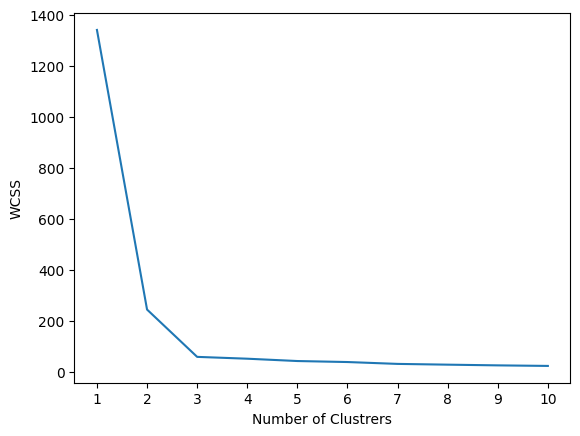

In [18]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [19]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [20]:
kmeans.fit_predict(X_train_scaled) ## We get cluster number for each point
## What it does internally: fit() -> Initialize centroids,Assign points to nearest centroid,Update centroids,Repeat until convergence,predict() ->Output cluster label for each point

array([2, 0, 2, 2, 0, 2, 2, 0, 1, 0, 2, 1, 2, 2, 2, 0, 2, 2, 1, 0, 2, 1,
       1, 2, 1, 1, 0, 1, 1, 0, 2, 2, 1, 2, 2, 2, 1, 1, 2, 1, 2, 2, 1, 0,
       2, 0, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 0,
       0, 0, 1, 2, 0, 2, 1, 0, 2, 0, 0, 0, 2, 1, 1, 1, 2, 1, 1, 0, 0, 1,
       1, 0, 2, 2, 1, 0, 0, 2, 1, 0, 2, 1, 0, 2, 1, 1, 2, 1, 0, 2, 2, 2,
       1, 0, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 2, 2, 2, 1, 1, 2, 0,
       0, 0, 0, 2, 0, 2, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 0, 2, 0, 2, 1, 1,
       2, 2, 1, 0, 2, 1, 2, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 2, 2, 0, 1, 2, 0, 0, 0, 2, 1, 1, 0, 1, 2, 1, 2, 0, 1, 2, 0, 0,
       2, 0, 1, 0, 2, 0, 1, 2, 1, 0, 0, 2, 2, 0, 0, 2, 0, 1, 1, 1, 0, 2,
       2, 0, 2, 2, 0, 1, 0, 2, 0, 1, 1, 2, 2, 0, 1, 2, 0, 0, 2, 1, 0, 0,
       0, 2, 0, 0, 0, 1, 2, 1, 0, 0, 0, 2, 2, 0, 1, 1, 2, 1, 0, 2, 0, 1,
       0, 0, 0, 1, 0, 2, 2, 1, 2, 2, 0, 1, 0, 1, 2, 0, 2, 2, 2, 1, 2, 0,
       0, 0, 0, 2, 2, 0, 1, 2, 0, 0, 0, 2, 2, 2, 0,

In [21]:
y_pred=kmeans.predict(X_test_scaled)

In [22]:
y_pred

array([2, 1, 1, 2, 2, 0, 1, 0, 1, 2, 1, 0, 2, 2, 2, 0, 0, 1, 1, 2, 1, 1,
       0, 2, 0, 1, 1, 0, 1, 0, 0, 0, 1, 2, 1, 0, 2, 0, 2, 0, 1, 2, 1, 1,
       0, 0, 0, 2, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1, 1, 1, 0, 2, 1, 1, 2, 1,
       0, 1, 2, 0, 1, 2, 2, 0, 0, 2, 2, 2, 1, 0, 2, 1, 1, 2, 0, 0, 0, 0,
       0, 0, 2, 1, 0, 2, 2, 2, 0, 2, 1, 0, 0, 2, 1, 1, 2, 0, 2, 1, 1, 0,
       2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 2, 1, 2, 1, 1, 1, 1, 0, 0, 1,
       0, 2, 1, 0, 2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1, 0, 0, 2, 2,
       2, 0, 2, 1, 2, 2, 0, 0, 2, 0, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 0, 2,
       1, 1, 1, 1, 1, 0, 1, 0, 2, 2, 2, 1, 1, 2, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 2, 2, 2, 0, 2, 0, 2, 1, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 0,
       1, 2, 1, 0, 1, 2, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 2, 0, 0, 2, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 2, 0, 0, 1, 2, 1, 2, 2, 1,
       2, 0, 1, 1, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 0, 1, 2, 2, 1, 1, 2, 0,
       1, 0, 2, 0, 2, 0, 2, 2, 1, 2, 0, 1, 1, 1, 1,

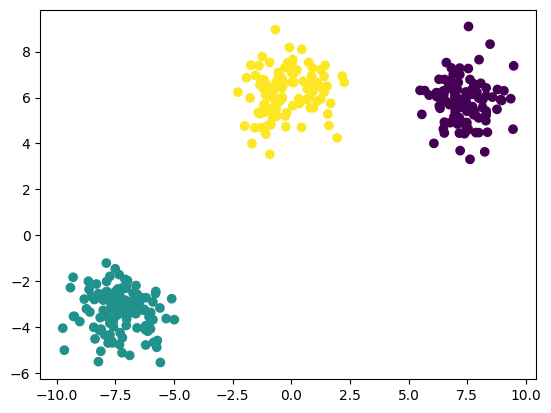

In [ ]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred) ## This plot is used only for visualization.It helps us see the clusters formed by K-Means.

In [24]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [ ]:
## kneelocator
!pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from kneed import KneeLocator ##KneeLocator -> Function from the kneed library that finds the elbow/knee point in a curve automatically.

In [27]:
## The important point is: curve and direction are not chosen randomly.They must match the shape of the graph you are analyzing.If not, we fail to detect elbow.
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
## range(1,11) ->Number of clusters K = 1 to 10 tested in K-Means, wcss ->Within Cluster Sum of Squares (inertia) corresponding to each K
## curve="convex" -> Tells the algorithm the curve shape is convex (bending downward), d ->irection="decreasing" -> Indicates the metric (WCSS) decreases as K increases

In [28]:
kl.elbow ## This gives the cluster number where the elbow occurs.

np.int64(3)

In [29]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [30]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    ## The function needs two inputs: silhouette_score(data, cluster_labels) 
    score=silhouette_score(X_train_scaled,kmeans.labels_)##Calculates the silhouette score for the clustering result.  ## X_train_scaled -> dataset points, kmeans.labels_ -> cluster assign to each point
    silhouette_coefficients.append(score)

In [31]:
silhouette_coefficients

[0.7500858859913764,
 0.7595567115777452,
 0.6018411216888305,
 0.4814913154203231,
 0.3581134433468847,
 0.34049895205791636,
 0.33120060176410193,
 0.342409792961852,
 0.32305884998408846]

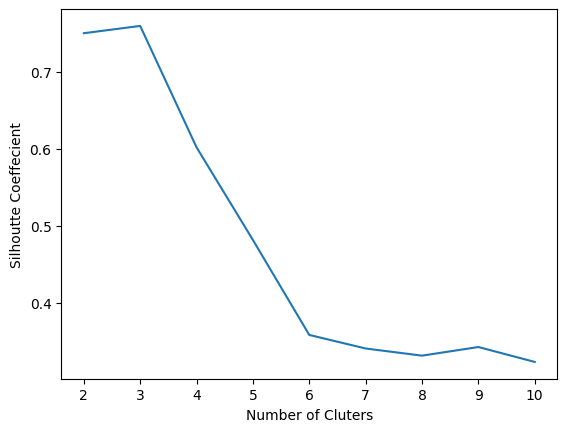

In [ ]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()
## The best K is the highest silhouette score. Finally, Optimal clusters = 3